# 11 · Numerical representation framework demo

A single workflow compares three aligned numerical spaces with the same observations. Ruddy remains agnostic to how each representation was produced and focuses on geometry, group structure, similarity and anomalies.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_pca, analyze_permutation_group_structure, analyze_representation_similarity, analyze_anomalies
frame,dataset=load_tabular_demo(); spaces={'Embedding-like':load_feature_demo('representation_a'),'Descriptor-like':load_feature_demo('representation_b'),'Structure-like':load_feature_demo('representation_c')}
pcs={name:analyze_pca(fm,n_components=3,scaling='standard') for name,fm in spaces.items()}
perms={name:analyze_permutation_group_structure(fm,dataset,factor='group',n_permutations=19,random_state=42) for name,fm in spaces.items()}
anoms={name:analyze_anomalies(fm,methods=('isolation_forest','lof'),scaling='standard',random_state=42) for name,fm in spaces.items()}
AB=analyze_representation_similarity(spaces['Embedding-like'],spaces['Descriptor-like'],cca_components=3,mantel_permutations=49,random_state=42)
AC=analyze_representation_similarity(spaces['Embedding-like'],spaces['Structure-like'],cca_components=3,mantel_permutations=49,random_state=42)
BC=analyze_representation_similarity(spaces['Descriptor-like'],spaces['Structure-like'],cca_components=3,mantel_permutations=49,random_state=42)

## Same observations, three numerical spaces

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


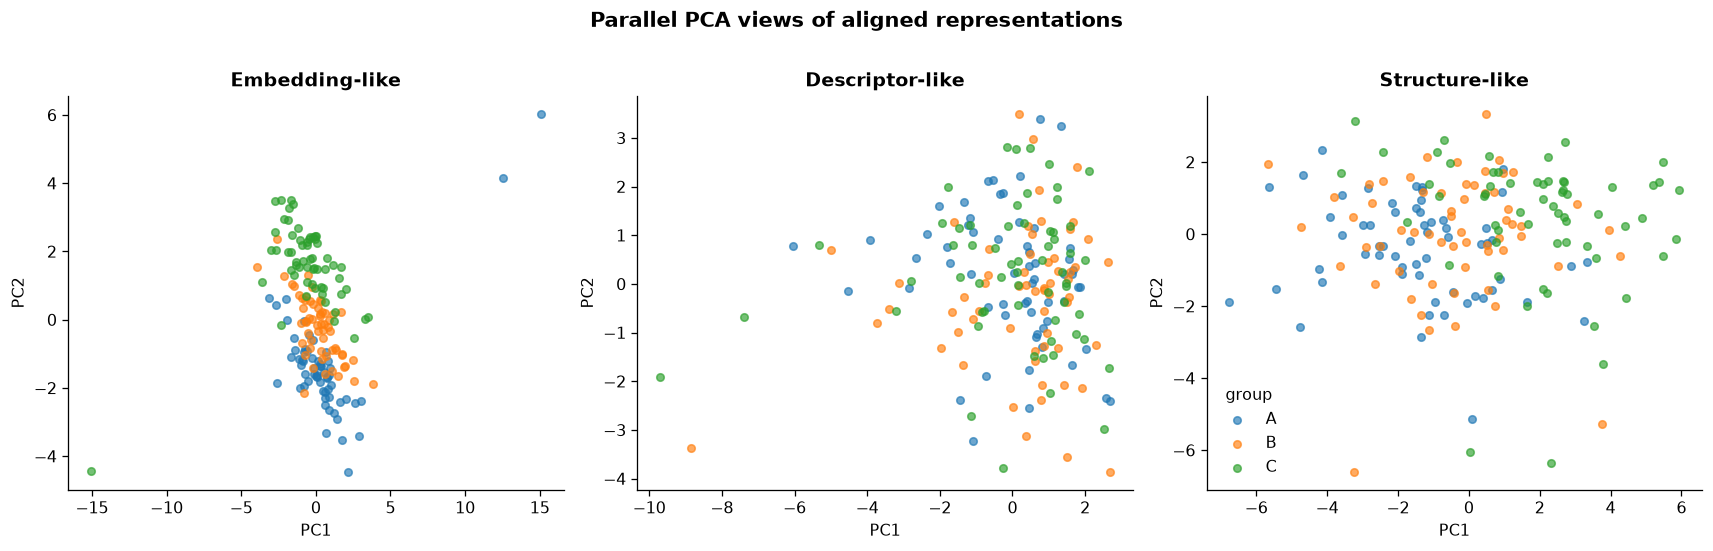

In [2]:
fig,axes=plt.subplots(1,3,figsize=(15,4.7));
for ax,(name,res) in zip(axes,pcs.items()):
    m=res.scores.merge(frame[['id','group']],left_on='observation_id',right_on='id');
    for level,sub in m.groupby('group'): ax.scatter(sub.PC1,sub.PC2,label=level,alpha=.65,s=22)
    ax.set_title(name); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes[-1].legend(title='group'); finish(fig,title='Parallel PCA views of aligned representations'); plt.show()

## Group separation strength across spaces

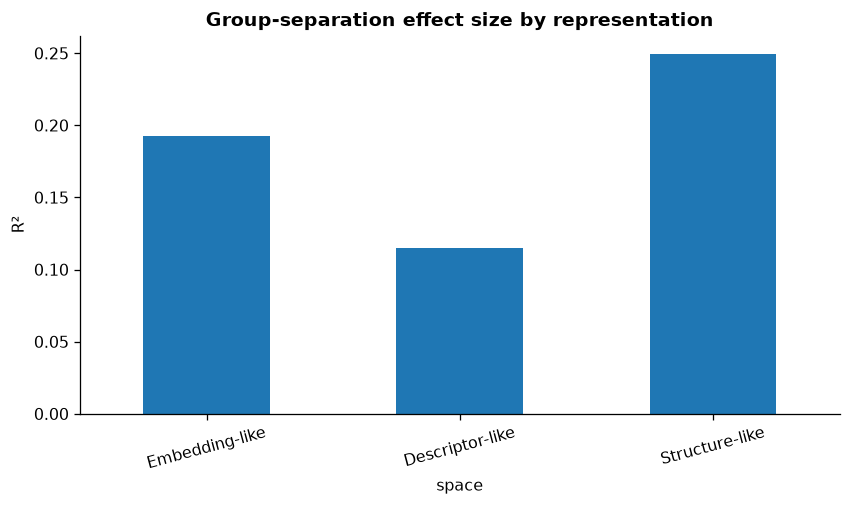

,PERMANOVA_R2,PERMANOVA_p,PERMDISP_p
space,,,
Embedding-like,0.192759,0.05,0.55
Descriptor-like,0.115268,0.05,0.90
Structure-like,0.249725,0.05,0.80


In [3]:
rows=[]
for name,res in perms.items():
    p=res.summary.query('analysis=="permanova"').iloc[0]; d=res.summary.query('analysis=="permdisp"').iloc[0]; rows.append({'space':name,'PERMANOVA_R2':p.r_squared,'PERMANOVA_p':p.p_value,'PERMDISP_p':d.p_value})
sep=pd.DataFrame(rows).set_index('space'); fig,ax=plt.subplots(figsize=(7.5,4.5)); sep[['PERMANOVA_R2']].plot(kind='bar',ax=ax,legend=False); ax.set_ylabel('R²'); ax.set_title('Group-separation effect size by representation'); ax.tick_params(axis='x',rotation=15); finish(fig); plt.show(); display(sep)

## Cross-representation CKA matrix

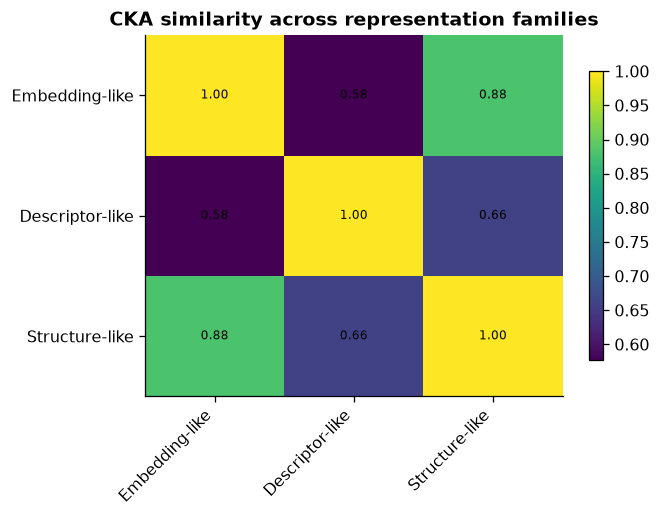

In [4]:
labels=list(spaces); cka=pd.DataFrame(np.eye(3),index=labels,columns=labels); pairvals={(0,1):AB.cka.iloc[0].cka,(0,2):AC.cka.iloc[0].cka,(1,2):BC.cka.iloc[0].cka};
for (i,j),v in pairvals.items(): cka.iat[i,j]=cka.iat[j,i]=v
matrix_heatmap(cka,title='CKA similarity across representation families'); plt.show()

## Geometry-preservation profile

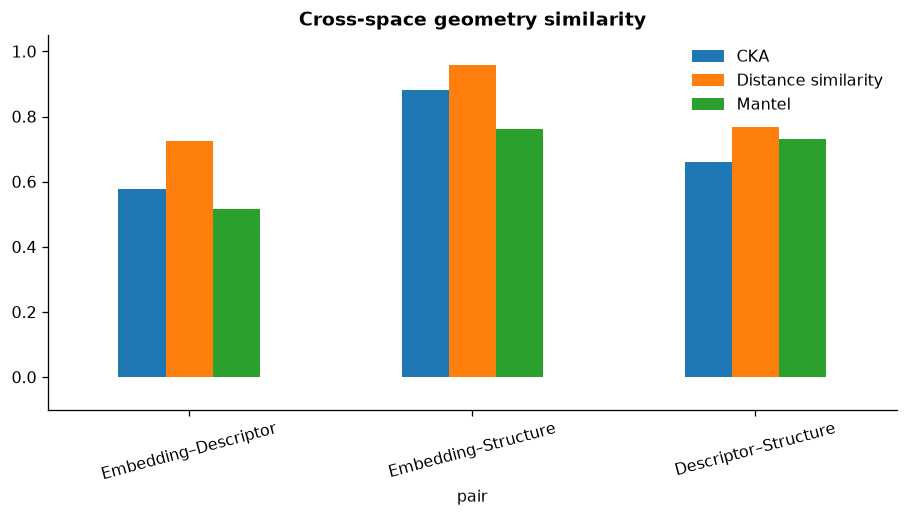

In [5]:
sim=pd.DataFrame([{'pair':'Embedding–Descriptor','CKA':AB.cka.iloc[0].cka,'Distance similarity':AB.distance_similarity.iloc[0].coefficient,'Mantel':AB.mantel.iloc[0].correlation},{'pair':'Embedding–Structure','CKA':AC.cka.iloc[0].cka,'Distance similarity':AC.distance_similarity.iloc[0].coefficient,'Mantel':AC.mantel.iloc[0].correlation},{'pair':'Descriptor–Structure','CKA':BC.cka.iloc[0].cka,'Distance similarity':BC.distance_similarity.iloc[0].coefficient,'Mantel':BC.mantel.iloc[0].correlation}]).set_index('pair'); fig,ax=plt.subplots(figsize=(8,4.6)); sim.plot(kind='bar',ax=ax); ax.set_ylim(-.1,1.05); ax.set_title('Cross-space geometry similarity'); ax.tick_params(axis='x',rotation=15); finish(fig); plt.show()

## Anomaly burden across representation spaces

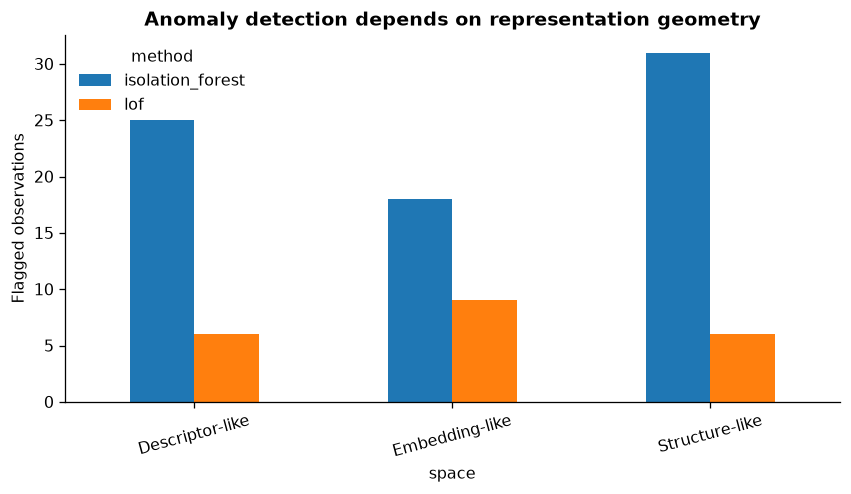

In [6]:
rows=[]
for name,res in anoms.items():
    for method,sub in res.scores.groupby('method'): rows.append({'space':name,'method':method,'n_flagged':int(sub.is_flagged.sum())})
flag=pd.DataFrame(rows); pivot=flag.pivot(index='space',columns='method',values='n_flagged'); fig,ax=plt.subplots(figsize=(7.5,4.4)); pivot.plot(kind='bar',ax=ax); ax.set_ylabel('Flagged observations'); ax.set_title('Anomaly detection depends on representation geometry'); ax.tick_params(axis='x',rotation=15); finish(fig); plt.show()

## Interactive side-by-side representation explorer

In [7]:
import plotly.express as px
long=[]
for name,res in pcs.items():
    t=res.scores[['observation_id','PC1','PC2']].merge(frame[['id','group','activity']],left_on='observation_id',right_on='id'); t['space']=name; long.append(t)
long=pd.concat(long,ignore_index=True)
fig=px.scatter(long,x='PC1',y='PC2',color='group',facet_col='space',hover_data=['observation_id','activity'],title='Interactive aligned-representation explorer')
fig